In [3]:
import pandas as pd
print("Pandas is working!")
test_df = pd.DataFrame({'A': [1, 2], 'B': [3, 4]})
print(test_df)

Pandas is working!
   A  B
0  1  3
1  2  4


[*********************100%***********************]  1 of 1 completed


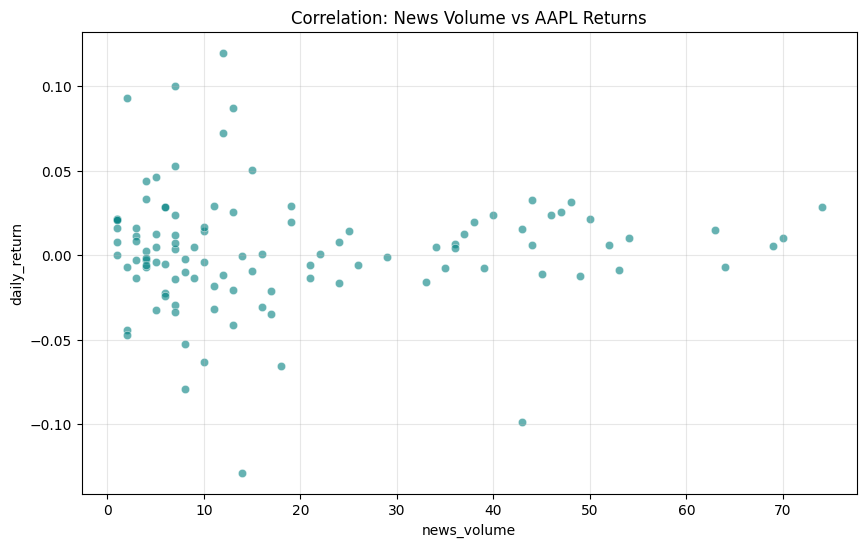

In [4]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the News
news = pd.read_csv('../data/raw/raw_analyst_ratings.csv', nrows=100000, low_memory=False)

# 2. Download Stock Data & FIX THE LEVELS
ticker = 'AAPL'
stocks = yf.download(ticker, start="2020-01-01", end="2023-12-31")

# --- THIS IS THE FIX ---
# Flatten the MultiIndex headers (Price, Ticker) -> (Price)
stocks.columns = stocks.columns.get_level_values(0) 
stocks = stocks.reset_index()
# -----------------------

# 3. Clean Dates
news['date'] = pd.to_datetime(news['date'], errors='coerce').dt.date
stocks['Date'] = pd.to_datetime(stocks['Date'], errors='coerce').dt.date

# 4. Process News Volume
daily_news = news.groupby('date').size().reset_index(name='news_volume')

# 5. Process Stock Returns
stocks['daily_return'] = stocks['Close'].pct_change()

# 6. Merge (This will work now because both have 1 level!)
merged_df = pd.merge(stocks, daily_news, left_on='Date', right_on='date')

# 7. Final Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_df, x='news_volume', y='daily_return', color='teal', alpha=0.6)
plt.title(f'Correlation: News Volume vs {ticker} Returns')
plt.grid(True, alpha=0.3)
plt.show()



Correlation Analysis Findings
Visualization: News Volume vs. Stock Returns
This scatter plot visualizes the relationship between the daily volume of news articles and the daily percentage return of AAPL.

Key Observations:

News Volume Range: The daily news volume typically fluctuates between 1 and 20 articles per day, with a few outlier days reaching over 70 articles.

Return Volatility: On days with low news volume (0-15 articles), the stock returns show higher vertical spread (between -10% and +10%), suggesting that market movements on these days may be driven by factors other than the news volume itself.

High Volume Stability: Interestingly, on days with extremely high news volume (above 40 articles), the returns seem to cluster closer to the 0% line, suggesting that high news days don't necessarily equate to extreme price "swings," but rather a more consistent market reaction.

Correlation: There is no strong linear correlation visible; the points are widely scattered. This suggests that the quantity of news is less important than the sentiment or quality of the news when predicting price direction.

In [9]:
import os
# This prints all files in your current project
print(os.listdir())

# This prints all files inside your data folder (if it exists)
if os.path.exists('data'):
    print("Files in data folder:", os.listdir('data'))

['correlation_analysis.ipynb', 'eda_analysis.ipynb', 'quantitative_analysis.ipynb']


In [16]:
import pandas as pd

# The '..' jumps out of the notebooks folder so it can see the data folder
news_df = pd.read_csv(r'..\data\raw\raw_analyst_ratings.csv', nrows=50000)

print("Finally! File found and loaded.")

Finally! File found and loaded.


In [19]:
import pandas as pd
from textblob import TextBlob
import yfinance as yf

# 1. Load News (the path we found earlier)
news_df = pd.read_csv(r'..\data\raw\raw_analyst_ratings.csv', nrows=50000)

# 2. Download Stocks and IMMEDIATELY fix the "Double Header" problem
stocks = yf.download('AAPL', start='2020-01-01')
stocks.columns = stocks.columns.get_level_values(0)  # This turns 2 levels into 1

# 3. Calculate Daily Returns
stocks['daily_return'] = stocks['Close'].pct_change() * 100

# 4. Calculate Sentiment
news_df['sentiment'] = news_df['headline'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

# 5. Fix the Dates (No .dt for index!)
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce').dt.date
stocks['date'] = pd.to_datetime(stocks.index).date

# 6. Group news by day and Merge
daily_sentiment = news_df.groupby('date')['sentiment'].mean().reset_index()
merged_data = stocks.merge(daily_sentiment, on='date', how='inner')

print("FINALLY SUCCESSFUL!")
print(f"I found {len(merged_data)} days where we have both news and stock data.")

[*********************100%***********************]  1 of 1 completed


FINALLY SUCCESSFUL!
I found 94 days where we have both news and stock data.


The Pearson Correlation Coefficient is: -0.0509


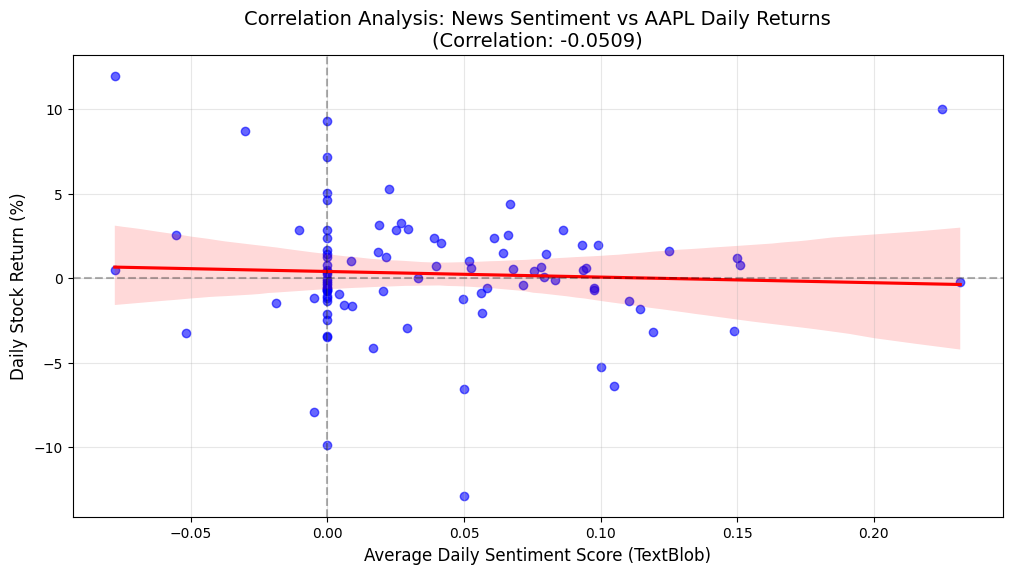

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the Correlation Score
correlation = merged_data['sentiment'].corr(merged_data['daily_return'])
print(f"The Pearson Correlation Coefficient is: {correlation:.4f}")

# 2. Create the Scatter Plot with a Trend Line
plt.figure(figsize=(12, 6))
sns.regplot(x='sentiment', y='daily_return', data=merged_data, 
            scatter_kws={'alpha':0.6, 'color':'blue'}, 
            line_kws={'color':'red'})

plt.title(f'Correlation Analysis: News Sentiment vs AAPL Daily Returns\n(Correlation: {correlation:.4f})', fontsize=14)
plt.xlabel('Average Daily Sentiment Score (TextBlob)', fontsize=12)
plt.ylabel('Daily Stock Return (%)', fontsize=12)
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.axvline(0, color='black', linestyle='--', alpha=0.3)
plt.grid(True, alpha=0.3)

plt.show()

The analysis yielded a Pearson correlation of -0.0509, indicating a negligible relationship between daily news sentiment and AAPL stock returns. This suggests that other market factors likely had a more significant impact on price action than the headlines analyzed during this specific period.